In [ ]:
#housekeeping

from google.colab import drive
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import LabelEncoder

from PIL import Image

from tensorflow.keras.models import load_model
from IPython.display import clear_output

In [ ]:
#mount drive and save dataset directory

drive.mount('/content/drive')
dataset = '/content/drive/My Drive/PVdatasetUpdated'

Mounted at /content/drive


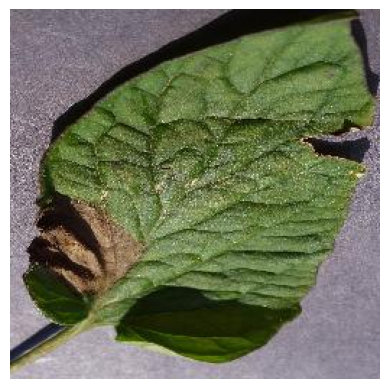

In [ ]:
#just testing that the image files from the mounted drive are accessable

img = mpimg.imread(dataset + '/Tomato/Train/Late Blight/ff735d59-0023-4c97-853c-ff4083ba96d6___RS_Late.B 6263.JPG')
plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
#gather all images and their labels into one dataframe
image_paths = []
labels = []
unique_labels = []
for plant_type in os.listdir(dataset):
  plant_path = os.path.join(dataset, plant_type)
  if not os.path.isdir(plant_path):
    continue

  for partition in os.listdir(plant_path):
    partition_path = os.path.join(plant_path, partition)
    if not os.path.isdir(partition_path):
      continue

    for label in os.listdir(partition_path):
      label_path = os.path.join(partition_path, label)
        #get the names of folders since they are labels: Healthy, Rust, etc.
      if not os.path.isdir(label_path):
        continue

      for img_file in os.listdir(label_path):
        img_file_path = os.path.join(label_path, img_file)
        if os.path.isfile(img_file_path) and img_file.lower().endswith(('jpg', 'jpeg', '.png')):
          #add full path to img_file to image_paths list
            #and label of the image (taken from folder name) to labels list
          image_paths.append(img_file_path)
          if label not in labels:
            unique_labels.append(label)
          labels.append(label)

labels_as_indexes = []
for label in labels:
  label_index = unique_labels.index(label)
  labels_as_indexes.append(label_index)

df = pd.DataFrame({
    "image": image_paths,
    "label": labels,
    "label_index": labels_as_indexes
})

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
#split main dataframe into training, validation, and testing datasets

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label_index"], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df["label_index"], random_state=42)

#turn the new dataframes into seperate lists of X input images and Y labels
X_train, y_train = train_df["image"].tolist(), train_df["label_index"].tolist()
X_val, y_val = val_df["image"].tolist(), val_df["label_index"].tolist()
X_test, y_test = test_df["image"].tolist(), test_df["label_index"].tolist()

#encode labels as numbers
'''encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_val_encoded = encoder.transform(y_val)
y_test_encoded = encoder.transform(y_test)'''

'encoder = LabelEncoder()\ny_train_encoded = encoder.fit_transform(y_train)\ny_val_encoded = encoder.transform(y_val)\ny_test_encoded = encoder.transform(y_test)'

Train: 42950 Validation: 10738 Test: 13423
Sample:
	 /content/drive/My Drive/PVdatasetUpdated/Peach/Train/Healthy/376521a0-fc29-441d-adfb-4fd31a02b643___Rutg._HL 2402_new30degFlipLR.JPG 
	 2


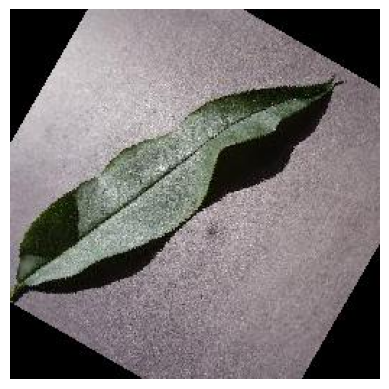

In [ ]:
#visualize data
print("Train:", len(X_train), "Validation:", len(X_val), "Test:", len(X_test))

for i in range(1):
  randnum = np.random.randint(0,len(X_train))
  print("Sample:\n\t", X_train[randnum],"\n\t", y_train[randnum])
  img = mpimg.imread(X_train[randnum])
  plt.imshow(img)
  plt.axis("off")
  plt.show()

In [ ]:
#build the model
'''
cnn = models.Sequential([
    #CNN
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(256,256,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', input_shape=(256,256,3)),
    layers.MaxPooling2D((2,2)),

    #RNN
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(16, activation='softmax')
    #outputs are numbers, need to map to text labels
])
'''

"\ncnn = models.Sequential([\n    #CNN\n    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(256,256,3)),\n    layers.MaxPooling2D((2,2)),\n    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', input_shape=(256,256,3)),\n    layers.MaxPooling2D((2,2)),\n\n    #RNN\n    layers.Flatten(),\n    layers.Dense(64, activation='relu'),\n    layers.Dense(16, activation='softmax')\n    #outputs are numbers, need to map to text labels\n])\n"

In [ ]:
'''
cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])
'''

"\ncnn.compile(optimizer='adam',\n            loss='sparse_categorical_crossentropy',\n            metrics=['accuracy'])\n"

In [ ]:
def load_images_from_paths(path_list):
    images = []
    target_size = (256, 256)
    for path in path_list:
        img = Image.open(path).convert("RGB")
        img = img.resize(target_size)
        img_array = np.array(img) / 255.0
        images.append(img_array)
    return np.array(images)

def close_images_from_paths(path_list):
  for path in path_list:
    Image.close(path)

In [ ]:
def slice_wrap(x, start, end):
    n = len(x)
    return [x[(start + i) % n] for i in range(end-start)]

def train_one_batch(cnn, batch_size, number_of_batches, batch_num, x_train, x_val, y_train, y_val):
  print("batch", batch_num, " of ", number_of_batches)

  start = batch_size*batch_num
  end = start+batch_size

  batch_xt = x_train[start:end]
  batch_yt = y_train[start:end]
  batch_xv = slice_wrap(x_val, start, end)
  batch_yv = slice_wrap(y_val, start, end)


  batch_train_img = load_images_from_paths(batch_xt)
  batch_val_img = load_images_from_paths(batch_xv)

  history = cnn.fit(
      batch_train_img,
      np.array(batch_yt),
      validation_data=(batch_val_img, np.array(batch_yv))
  )
  return history

def train_in_batches(cnn, batch_size, number_of_batches, x_train, x_val, y_train, y_val):
  for batch_num in range(number_of_batches):
    train_one_batch(cnn, batch_size, batch_num, x_train, x_val, y_train, y_val)

def test_in_batches(cnn, batch_size, x_test, y_test):
  number_of_batches = int(np.ceil( len(x_test)/batch_size ))

  for batch_num in range(number_of_batches):
    start = batch_size*batch_num
    end = start + batch_size

    batch_x = x_test[start:end]
    batch_y = y_test[start:end]

    batch_img = load_images_from_paths(batch_x)

    evaluation = cnn.evaluate(batch_img, np.array(batch_y))

    loss, accuracy = evaluation[0], evaluation[1]
    metrics_frame = pd.DataFrame({
      "Testing Accuracy": [accuracy],
      "Testing Loss": [loss]
    })
    metrics_frame.to_csv(metrics_history_path, mode="a", header=False, index=False)

In [ ]:
'''with open('/content/drive/My Drive/plantVis2/train_history.txt', 'w') as f:
  f.write('0')
with open('/content/drive/My Drive/plantVis2/train_history.txt', 'r') as f:
 batch_num = int(f.read())
 print(batch_num)'''

"with open('/content/drive/My Drive/plantVis2/train_history.txt', 'w') as f:\n  f.write('0')\nwith open('/content/drive/My Drive/plantVis2/train_history.txt', 'r') as f:\n batch_num = int(f.read())\n print(batch_num)"

In [ ]:
saved_model_path = "/content/drive/My Drive/plantVis2/plantVis2.keras"
history_path = "/content/drive/My Drive/plantVis2/train_history.txt"
metrics_history_path = "/content/drive/My Drive/plantVis2/training_metrics_epoch2.csv"

batch_size = 64
number_of_batches = int(np.ceil( len(X_train)/batch_size ))
batches_at_once = 25
batch_num = 0

train_acc = []
train_loss = []
val_acc = []
val_loss = []

while batch_num < number_of_batches-1:
  #been having issues with colab crashing/closing while I'm gone, so broke epochs into sessions
  #sessions are an arbitrary number of batches
  #model saved to drive after each session so progress isn't lost if runtime ends

  #read the last batch_num from drive file
  with open(history_path, "r") as file:
    content = file.read()
  if content != "":
    batch_num = int(content)
  else:
    batch_num = 999999999

  loaded_cnn = load_model(saved_model_path)

  #train a handfule of batches in one go
  for i in range(batches_at_once):
    history = train_one_batch(loaded_cnn, batch_size, number_of_batches, batch_num, X_train, X_val, y_train, y_val)
    batch_num +=1
    train_acc.extend(history.history['accuracy'])
    train_loss.extend(history.history['loss'])
    val_acc.extend(history.history['val_accuracy'])
    val_loss.extend(history.history['val_loss'])

  #save model to drive, and record what batch number was left off on
  loaded_cnn.save(saved_model_path)
  with open(history_path, "w") as file:
    file.write(str(batch_num))

  #save metrics history
  metrics_frame = pd.DataFrame({
    "Training Accuracy": train_acc,
    "Training Loss": train_loss,
    "Validation Accuracy": val_acc,
    "Validation Loss": val_loss
  })
  metrics_frame.to_csv(metrics_history_path, mode="a", header=False, index=False)

  #illustrate metrics history each session
  clear_output(wait=True)
  fig, axes = plt.subplots(2, 1, figsize=(8,10))

  axes[0].plot(metrics_frame.index, metrics_frame['Training Accuracy'], label="Training Accuracy", linewidth=2)
  axes[0].plot(metrics_frame.index, metrics_frame['Validation Accuracy'], label="Validation Accuracy", linewidth=2)
  axes[0].set_xlabel("Session")
  axes[0].set_ylabel("Value")
  axes[0].set_title("Accuracy Over Batches")
  axes[0].legend(title="Metrics")
  axes[0].grid(True)

  axes[1].plot(metrics_frame.index, metrics_frame['Training Loss'], label="Training Loss", linewidth=2)
  axes[1].plot(metrics_frame.index, metrics_frame['Validation Loss'], label="Validation Loss", linewidth=2)
  axes[1].set_xlabel("Session")
  axes[1].set_ylabel("Value")
  axes[1].set_title("Loss Over Batches")
  axes[1].legend(title="Metrics")
  axes[1].grid(True)

  plt.tight_layout()
  plt.show()

avg_train_acc = np.mean(train_acc)
avg_train_loss = np.mean(train_loss)
avg_val_acc = np.mean(val_acc)
avg_val_loss = np.mean(val_loss)
print("average training accuracy:", avg_train_acc,
      "\naverage training loss:", avg_train_loss,
      "\naverage validation accuracy:", avg_val_acc,
      "\naverage validation loss", avg_val_loss
)

loaded_cnn.save(saved_model_path)
with open(history_path, "w") as file:
  file.write(str(batch_num))


batch 650  of  672


KeyboardInterrupt: 

In [ ]:
'''
with open("/content/drive/My Drive/plantVis2/test_history_epoch2.txt", "w") as file:
  file.write(str())

testing_frame = pd.DataFrame({
    "Testing Accuracy":[],
    "Testing Loss":[]
})

testing_frame.to_csv("/content/drive/My Drive/plantVis2/testing_history_epoch2.csv", index=False)

#illustrate metrics history each session
clear_output(wait=True)
fig, axes = plt.subplots(2, 1, figsize=(8,10))

axes[0].plot(metrics_frame.index, metrics_frame['Training Accuracy'], label="Training Accuracy", linewidth=2)
axes[0].plot(metrics_frame.index, metrics_frame['Validation Accuracy'], label="Validation Accuracy", linewidth=2)
axes[0].set_xlabel("Session")
axes[0].set_ylabel("Value")
axes[0].set_title("Accuracy Over Sessions")
axes[0].legend(title="Metrics")
axes[0].grid(True)

axes[1].plot(metrics_frame.index, metrics_frame['Training Loss'], label="Training Loss", linewidth=2)
axes[1].plot(metrics_frame.index, metrics_frame['Validation Loss'], label="Validation Loss", linewidth=2)
axes[1].set_xlabel("Session")
axes[1].set_ylabel("Value")
axes[1].set_title("Loss Over Sessions")
axes[1].legend(title="Metrics")
axes[1].grid(True)

plt.tight_layout()
plt.show()
'''

In [ ]:
test_in_batches(loaded_cnn, batch_size, X_test, y_test)